In [1]:
import cloudpickle as pickle
from datetime import datetime
import jax
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path

from utils import *
from model_definition.network_model_utils import *
from tvboptim.types import Parameter, BoundedParameter

jax.config.update("jax_enable_x64", True)

Cache stored here: c:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\cache\ei_tuning


In [2]:
# Set directory information
data_dir = "./"
cond0_filename = "TS_Control.npy"
cond1_filename = "TS_Schizo.npy"
result_dir = "./results/"

# Set dataset parameters
n_sub = 48
n_nodes = 68 # size of network for AAL90
conds = ['CTR', 'SCZ']
n_cond = len(conds) # number of conditions

# Simulation parameters
t1 = 314_000   # Simulation duration (ms) matching empirical data (=304_000) + transient time (~10_000 ms)
dt = 4.0      # Integration timestep (ms) matching original script
bold_TR = 2000.0 # BOLD sampling period (ms)
transient_lim = 5 # Number of time points to remove as transient (transient_lim * dt ms)
target_fic = 0.25  # FIC tuning parameter: Target excitatory activity level

# Gradient descent parameters
learning_rate = 0.0325
max_steps = 120

# Other parameters
n_tau = 2 # number of lags for lagged FC

### Load time-series BOLD data 

In [3]:
new_array = load_and_organize_bold(data_dir = data_dir, cond0_filename = cond0_filename, cond1_filename = cond1_filename,
                                   n_sub = n_sub, n_nodes = n_nodes)

### Compute time-lagged matrices

In [4]:
Q0_emp_all = np.zeros((n_sub, n_nodes, n_nodes, n_cond))  # shape: (n_sub, n_tau, n_nodes, n_nodes, n_cond)
Q1_emp_all = np.zeros((n_sub, n_nodes, n_nodes, n_cond))

for participant_idx in range(n_sub):
    for condition_idx in range(n_cond):
        # Get empirical time series of interest 
        ts = new_array[participant_idx,:,:,condition_idx]
        # Take the transpose for the lagged FC matrices computation
        X_emp = ts.T
    
        # Z-score the empirical time series per region
        z_scored_emp = z_score_per_region(X_emp)

        # Compute empirical lagged FC matrices
        Q_emp_single = lagged_fc_matrices(z_scored_emp, n_tau=n_tau, diag_zero=True)
        Q0_emp_single = Q_emp_single[0]  # FC0 (zero-lag)
        Q1_emp_single = Q_emp_single[1]  # FC1 (lag-1)

        Q0_emp_all[participant_idx, :, :, condition_idx] = Q0_emp_single
        Q1_emp_all[participant_idx, :, :, condition_idx] = Q1_emp_single
    
print("Empirical time series shape (time points x regions):", X_emp.shape)
print("Empirical FC0 shape (regions x regions):", Q0_emp_all.shape)
print("Empirical FC1 shape (regions x regions):", Q1_emp_all.shape)

Empirical time series shape (time points x regions): (152, 68)
Empirical FC0 shape (regions x regions): (48, 68, 68, 2)
Empirical FC1 shape (regions x regions): (48, 68, 68, 2)


### Plot Q0 and Q1 for two subjects

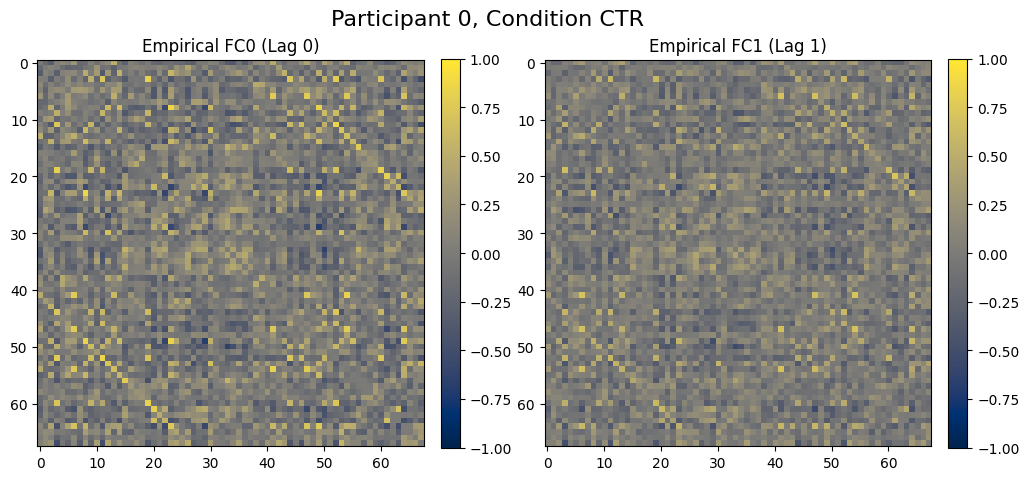

In [5]:
subj_plot_index = 0  # Index for the participant and condition to plot
cond_plot_index = 0  # Index for the condition to plot

Q0_emp_plot = Q0_emp_all[subj_plot_index, :, :, cond_plot_index]  # FC0 for the selected participant and condition
Q1_emp_plot = Q1_emp_all[subj_plot_index, :, :, cond_plot_index]  # Q1 for the selected participant and condition

# Plot Q 0 and Q 1 for both empirical and simulated data
fig, axes = plt.subplots(1,2, figsize=(12, 10))
# FC0 - Empirical
im0 = axes[0].imshow(Q0_emp_plot, vmin=-1, vmax=1, cmap='cividis')
axes[0].set_title('Empirical FC0 (Lag 0)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
# FC1 - Empirical
im2 = axes[1].imshow(Q1_emp_plot, vmin=-1, vmax=1, cmap='cividis')
axes[1].set_title('Empirical FC1 (Lag 1)')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
plt.suptitle(f'Participant {subj_plot_index}, Condition {conds[cond_plot_index]}', fontsize=16, y=0.739)
plt.show()

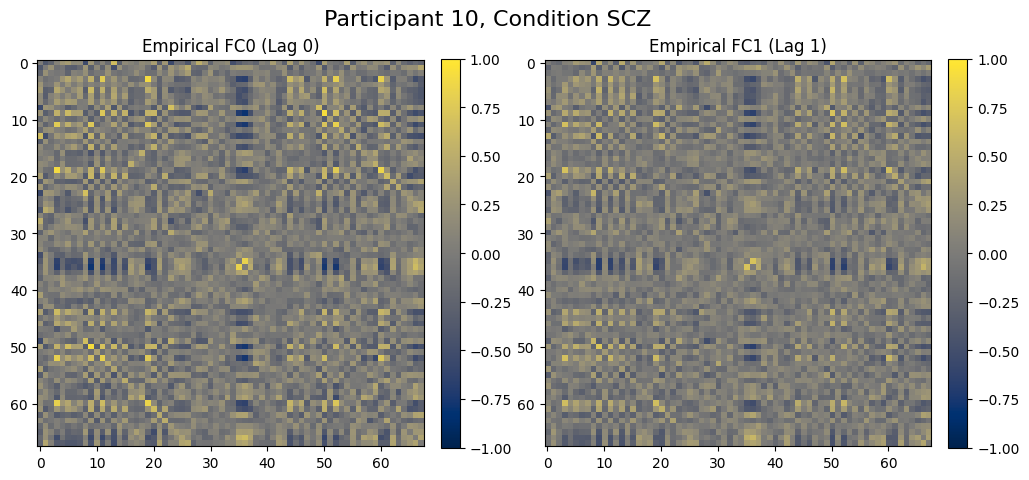

In [6]:
subj_plot_index = 10  # Index for the participant and condition to plot -> from 0 to 47
cond_plot_index = 1  # Index for the condition to plot -> 0 or 1

Q0_emp_plot = Q0_emp_all[subj_plot_index, :, :, cond_plot_index]  # FC0 for the selected participant and condition
Q1_emp_plot = Q1_emp_all[subj_plot_index,:, :, cond_plot_index]  # FC1 for the selected participant and condition

# Plot FC 0 and FC 1 for both empirical and simulated data
fig, axes = plt.subplots(1,2, figsize=(12, 10))
# FC0 - Empirical
im0 = axes[0].imshow(Q0_emp_plot, vmin=-1, vmax=1, cmap='cividis')
axes[0].set_title('Empirical FC0 (Lag 0)')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
# FC1 - Empirical
im2 = axes[1].imshow(Q1_emp_plot, vmin=-1, vmax=1, cmap='cividis')
axes[1].set_title('Empirical FC1 (Lag 1)')
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
plt.suptitle(f'Participant {subj_plot_index}, Condition {conds[cond_plot_index]}', fontsize=16, y=0.739)
plt.show()

### Load structural connectivity data

In [5]:
sc_path = 'SC_EnigmadK68.mat'
tl_path = 'tract_lengths.csv'
centers_path = 'centers.txt'

weights, delays, labels = load_structural_connectivity(sc_filepath=sc_path, tl_filepath=tl_path, centers_filepath=centers_path)

### Build the model to optimize

In [6]:
# Build a single network model using the structural connectivity and region labels
network = build_network_model(weights=weights, labels=labels)

Network created with 68 nodes


### Run initial simulation

In [7]:
model, state, result_init = run_initial_simulation(t1=t1, dt=dt, network=network)

Running initial transient simulation...
Initial simulation complete. Final S_e mean: 0.856
Initial simulation complete. Final S_i mean: 0.949


### Set up BOLD monitor

In [8]:
bold_monitor_opt = setup_bold_monitor(bold_TR = bold_TR, result_init = result_init)

BOLD monitor initialized


In [9]:
network.update_history(result_init)

model_opt, state_opt, _ = run_initial_simulation(t1=t1, dt=dt, network = network, verbose=False)

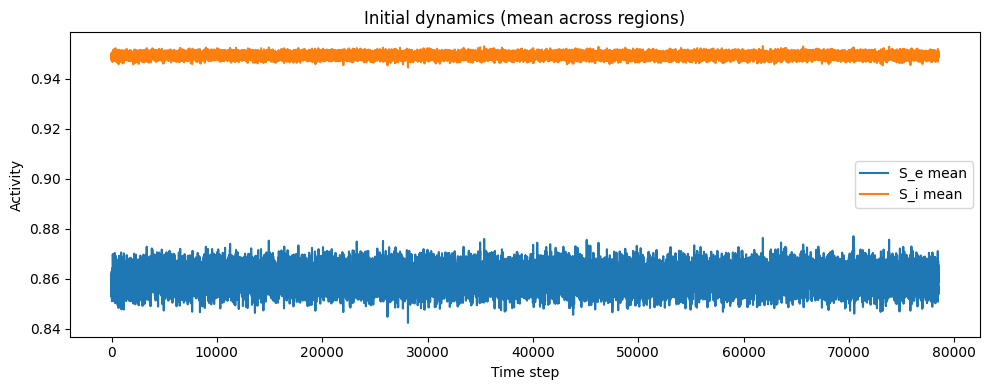

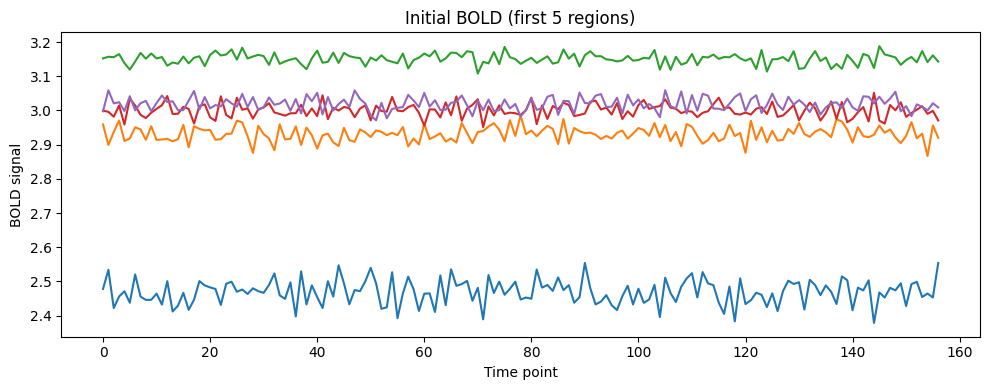

In [12]:
# Quick sanity check: plot mean S_e/S_i and BOLD after the initial model_opt setup
ts_check = model_opt(state_opt)
s_e_mean = jnp.mean(ts_check.data[:, 0, :], axis=1)
s_i_mean = jnp.mean(ts_check.data[:, 1, :], axis=1)

plt.figure(figsize=(10, 4))
plt.plot(s_e_mean, label="S_e mean")
plt.plot(s_i_mean, label="S_i mean")
plt.title("Initial dynamics (mean across regions)")
plt.xlabel("Time step")
plt.ylabel("Activity")
plt.legend()
plt.tight_layout()
plt.show()

bold_check = bold_monitor_opt(ts_check)
bold_signal = bold_check.data.reshape(bold_check.data.shape[0], bold_check.data.shape[-1])
plt.figure(figsize=(10, 4))
plt.plot(bold_signal[:, :5])
plt.title("Initial BOLD (first 5 regions)")
plt.xlabel("Time point")
plt.ylabel("BOLD signal")
plt.tight_layout()
plt.show()

In [13]:
single_subject = False # Set to True to optimize for only one participant and condition

if single_subject:
    Q0_emp = Q0_emp_all[0, :, :, 0]  # FC0 for the first participant and first condition
    Q1_emp = Q1_emp_all[0, :, :, 0]

    loss = make_loss(
        model_opt=model_opt,
        bold_monitor_opt=bold_monitor_opt,
        Q0_emp=Q0_emp,
        Q1_emp=Q1_emp,
        target_fic=target_fic,
        alpha_fc0=1.0,
        beta_fc1=2.0
    )

    # Evaluate initial loss
    initial_loss = loss(state_opt)
    print(f"Initial loss: {initial_loss:.4f}")

    # Mark parameters for optimization (J_i, wLRE, wFFI) with appropriate constraints
    state_opt.dynamics.J_i = Parameter(state_opt.dynamics.J_i)
    state_opt.coupling.coupling.wLRE = BoundedParameter(jnp.ones((n_nodes, n_nodes)), low=0.0, high=jnp.inf)
    state_opt.coupling.coupling.wFFI = BoundedParameter(jnp.ones((n_nodes, n_nodes)), low=0.0, high=jnp.inf)

### Setup evaluation model

In [10]:
# Will be populated after initial simulation completes
model_eval, state_eval, _state = None, None, None

print("Utility functions defined")

model_eval, state_eval, _state = setup_eval_model(t1=t1, dt=dt, network=network)

Utility functions defined


In [11]:
# Compute Q before gradient descent optimization
print("Computing pre-gradient descent functional connectivity...")
Q0_pre_gd, Q1_pre_gd = eval_Q0_Q1(
    model_eval, state_eval, bold_monitor_opt
)

Computing pre-gradient descent functional connectivity...


### Beggining of multisubject test

In [18]:
Q0_emp_all.shape

(48, 68, 68, 2)

In [ ]:
Q0_emp_all[participant_idx, :, :, condition_idx].shape

(68, 68)

In [12]:
# Test for scaling up - later substitute with n_sub and n_cond defined at the beggining of script
n_sub_test = 1
n_cond_test = 2

# Define ranges for participants and conditions for testing
participant_range_test= range(n_sub_test)
cond_range_test = range(n_cond_test)

In [ ]:
optimized_states_test = np.empty((n_sub_test, n_cond_test), dtype=object)
optimized_fits_test = np.empty((n_sub_test, n_cond_test), dtype=object)

for participant_idx in participant_range_test:
    for condition_idx in cond_range_test:
        print(f"Testing participant {participant_idx}, condition {condition_idx}")

        Q0_emp = Q0_emp_all[participant_idx, :, :, condition_idx]  # FC0 for the first participant and first condition
        Q1_emp = Q1_emp_all[participant_idx, :, :, condition_idx]

        print(f"Empirical FC0 shape: {Q0_emp.shape}, Empirical FC1 shape: {Q1_emp.shape}")

        loss = make_loss(
            model_opt=model_opt,
            bold_monitor_opt=bold_monitor_opt,
            Q0_emp=Q0_emp,
            Q1_emp=Q1_emp,
            target_fic=target_fic,
            alpha_fc0=1.0,
            beta_fc1=2.0
        )

        # Evaluate initial loss
        initial_loss = loss(state_opt)
        print(f"Initial loss: {initial_loss:.4f}")

        # Mark parameters for optimization (J_i, wLRE, wFFI) with appropriate constraints
        state_opt.dynamics.J_i = Parameter(state_opt.dynamics.J_i)
        state_opt.coupling.coupling.wLRE = BoundedParameter(jnp.ones((n_nodes, n_nodes)), low=0.0, high=jnp.inf)
        state_opt.coupling.coupling.wFFI = BoundedParameter(jnp.ones((n_nodes, n_nodes)), low=0.0, high=jnp.inf)

        optimized_state_temp, optimized_fit_temp = run_gradient_optimization(max_steps, learning_rate, loss, state_opt)
        optimized_states_test[participant_idx, condition_idx] = optimized_state_temp
        optimized_fits_test[participant_idx, condition_idx] = optimized_fit_temp

Testing participant 0, condition 0
Empirical FC0 shape: (68, 68), Empirical FC1 shape: (68, 68)
Initial loss: 1.0224
Running computations for gradient_optimization
LR: 0.0325
Step 0: 1.022387
Step 1: 0.990873
Step 2: 0.949785
Step 3: 0.894931
Step 4: 0.824909
Step 5: 0.748729
Step 6: 0.671743
Step 7: 0.657772
Step 8: 0.660105
Step 9: 0.666513
Step 10: 0.668386
Step 11: 0.670046
Step 12: 0.670178
Step 13: 0.670381
Step 14: 0.670262
Step 15: 0.670172
Step 16: 0.669604
Step 17: 0.668612
Step 18: 0.668425
Step 19: 0.667949
Step 20: 0.667205
Step 21: 0.666343
Step 22: 0.665203
Step 23: 0.664011
Step 24: 0.661765
Step 25: 0.660532
Step 26: 0.659364
Step 27: 0.658682
Step 28: 0.658121
Step 29: 0.655692
Step 30: 0.654133
Step 31: 0.652528
Step 32: 0.650627
Step 33: 0.648125
Step 34: 0.645880
Step 35: 0.642598
Step 36: 0.639658
Step 37: 0.636298
Step 38: 0.633868
Step 39: 0.629776
Step 40: 0.623735
Step 41: 0.619604
Step 42: 0.614332
Step 43: 0.607345
Step 44: 0.602240
Step 45: 0.597324
Step 46

### Save results

In [23]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pikl_name = f"part2_saved_state_{timestamp}.pkl"
save_path = Path(os.path.join(result_dir, pikl_name))

to_save = {
    "model_eval": model_eval,
    "state_eval": state_eval,
    "model_opt": model_opt,
    "optimized_states": optimized_states_test,
    "optimized_fits": optimized_fits_test,
}

with save_path.open("wb") as f:
    pickle.dump(to_save, f)

print(f"Saved variables to {save_path.resolve()}")

Saved variables to C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\part2_saved_state_20260324_1529.pkl


### Retrieve results

In [13]:
save_file_name = "part2_saved_state_20260324_1529.pkl"
save_path = Path(os.path.join(result_dir, save_file_name))

with save_path.open("rb") as f:
    loaded = pickle.load(f)

required_keys = {"model_opt", "model_eval", "state_eval", "optimized_states", "optimized_fits"}
missing = required_keys - set(loaded.keys())
if missing:
    raise KeyError(f"Missing keys in saved data: {sorted(missing)}")

print("Loaded keys:", sorted(loaded.keys()))
print("Loaded types:", {k: type(v).__name__ for k, v in loaded.items()})

model_opt = loaded["model_opt"]
model_eval = loaded["model_eval"]
state_eval = loaded["state_eval"]
optimized_states_test = loaded["optimized_states"]
optimized_fits_test = loaded["optimized_fits"]

Loaded keys: ['model_eval', 'model_opt', 'optimized_fits', 'optimized_states', 'state_eval']
Loaded types: {'model_eval': 'function', 'state_eval': 'Bunch', 'model_opt': 'function', 'optimized_states': 'ndarray', 'optimized_fits': 'ndarray'}


### Compute quality metrics

In [14]:
new_result_dir = f"./results/{learning_rate}_{max_steps}/"
compute_quality_metrics(t1, bold_TR, transient_lim, n_nodes, n_sub_test, n_cond_test, 
                            Q0_emp_all, Q1_emp_all, Q0_pre_gd, Q1_pre_gd, 
                            model_opt, optimized_states_test, optimized_fits_test,  bold_monitor_opt, 
                            result_dir = new_result_dir, conds = ["CTR", "SCZ"], verbose=False)

Participants:   0%|          | 0/1 [00:00<?, ?it/s]

Participants: 100%|██████████| 1/1 [00:08<00:00,  8.41s/it]


### End of part 2 of test